# Cloud liquid water frequency — Barrow strip

Loads the ERA5 archive **once**, then draws each figure from that in-memory
state. Re-running a single figure cell costs a second or two; the load cell is
the only slow step, and it only has to run again if you change the region,
season, years, or thresholds.

Everything here comes from `analyze_cloud_liquid_frequency.py` — this notebook
holds no analysis code of its own, so the two cannot drift apart. Editing the
module and re-running a figure cell picks up the change (autoreload is on).

| Cell | What it does |
|---|---|
| Load | `prepare()` → an `Analysis` holding masks, daily/monthly aggregates, quantiles |
| Report | the numeric summary the command line prints |
| Figures 1–7 | one cell each, independent of the others |

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import analyze_cloud_liquid_frequency as acl

# open_mfdataset warns about join/compat defaults changing; the module pins both
# explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use --dpi

# Set to a directory to write PNGs as well as display them; None displays only.
# SAVE_DIR = None
SAVE_DIR = Path("figures")
# SAVE_DIR = Path("figures/Clouds")

## Load the data

The slow cell. `prepare()` takes the same options as the command line, by
keyword — `region`, `years`, `season_start`, `season_end`, `lwp_threshold`,
`iwp_threshold`, `min_cloud_fraction`, `min_season_coverage`, `ocean_only`,
`include_precip`, `storage`, `data_root`, `lwp_bin_min/max`, `lwp_bins`,
`hist_layout`, `dpi`.

Anything you leave out keeps its command-line default.

In [2]:
A = acl.prepare(
    region="barrow",
    years=tuple(range(2015, 2026)),   # season START years
    season_start=(8, 1),
    season_end=(3, 31),
    lwp_threshold=0.1,                   # g m-2
    iwp_threshold=0.1,                   # g m-2
    min_cloud_fraction=0.99,
    include_precip=True,
    storage="local",
    dpi=350,
)

Cloud liquid water frequency
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Season     : 08-01 to 03-31  (wraps the new year)
  Cloudy scene: tcc >= 0.99 AND (LWP > 0.1 or IWP > 0.1) g m-2
  Liquid      : LWP > 0.1 g m-2 (0.0001 kg m-2)
  Domain      : all cells, land included

  Seasons found (11), coverage of the 244-day window:
    2015/16: 100.0%
    2016/17:  99.6%
    2017/18:  95.1%
    2018/19:  99.6%
    2019/20: 100.0%
    2020/21:  99.6%
    2021/22:  99.6%
    2022/23:  99.6%
    2023/24: 100.0%
    2024/25:  99.6%
    2025/26:  99.6%
  Using 11 season(s): 2015/16, 2016/17, 2017/18, 2018/19, 2019/20, 2020/21, 2021/22, 2022/23, 2023/24, 2024/25, 2025/26
  Cells       : 2,501   time steps: 63,960


## Numeric report

Optional — the figures do not depend on it.

In [3]:
acl.print_report(A)


------------------------------------------------------------------------
  (1) OVERALL, whole record, accepted seasons only
------------------------------------------------------------------------
    cell-hours considered           :    159,963,960
    cell-hours cloudy               :     98,424,753   (60.79% by area)
    cell-hours cloudy + liquid      :     79,999,409   (49.81% by area)
    cell-hours liquid, ANY cloud    :    121,729,691   (76.87% by area)
    fraction of cloudy scenes with liquid :  81.93%
    mean hours per cell, cloudy     :   39,354 h
    mean hours per cell, liquid     :   31,987 h

    Sensitivity to --lwp-threshold (fraction of cloudy scenes):
          g m-2    kg m-2   fraction
              0         0     87.65%
              1     0.001     71.09%
              5     0.005     61.21%
             10      0.01     55.09%
             20      0.02     47.26%
             50      0.05     33.16%

----------------------------------------------------------

## Figures

Each cell is self-contained: it reads `A` and returns a `matplotlib` figure.
Pass `out_dir=` to save. Nothing below re-reads the archive.

### 1. Monthly cloudy and liquid hours

Hours per cell per month, overcast vs overcast-and-liquid, plus the share of cloudy scenes carrying liquid.

  -> figures/barrow_cloud_liquid_monthly.png


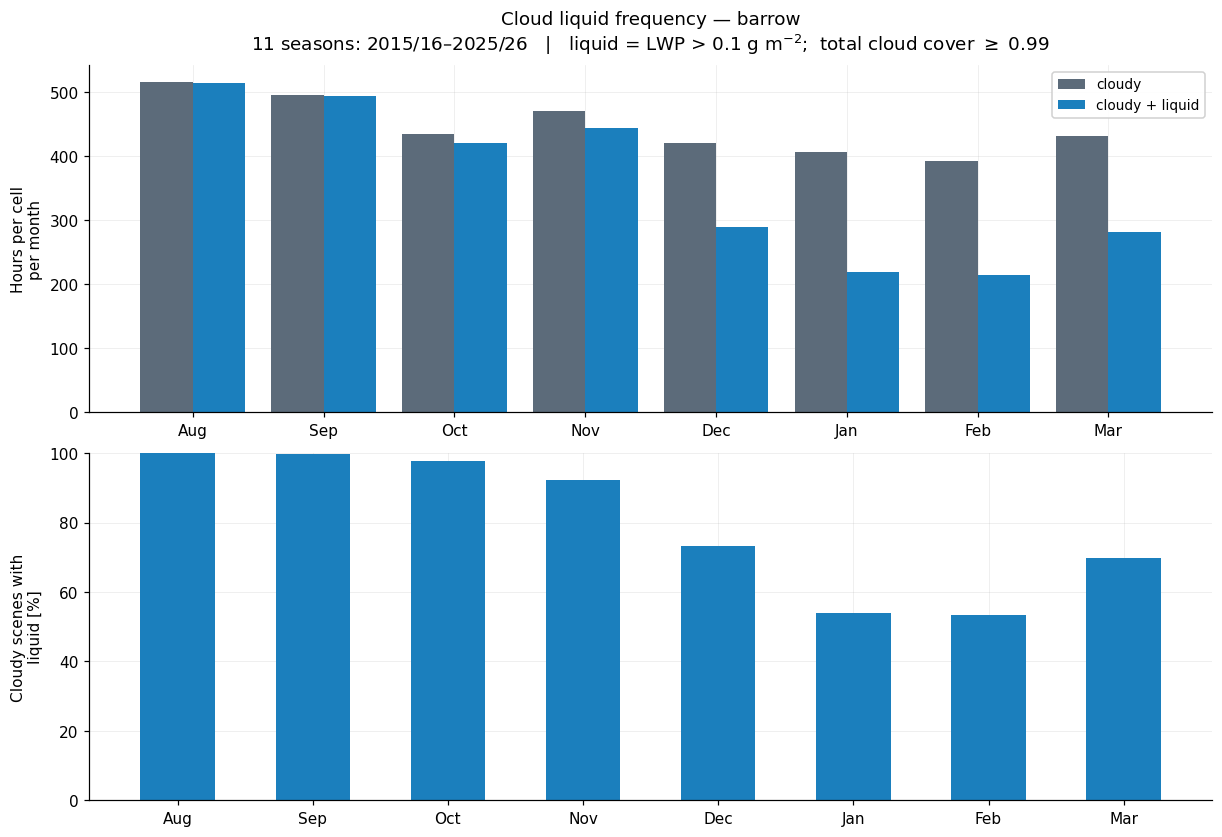

In [5]:
acl.fig_monthly_liquid(A, out_dir=SAVE_DIR);

### 2. Daily cloudy and liquid hours

Same quantities by day of season. Each season-day is collapsed to one **area mean** over the strip; the band is the spread across seasons.

  -> figures/barrow_cloud_liquid_daily.png


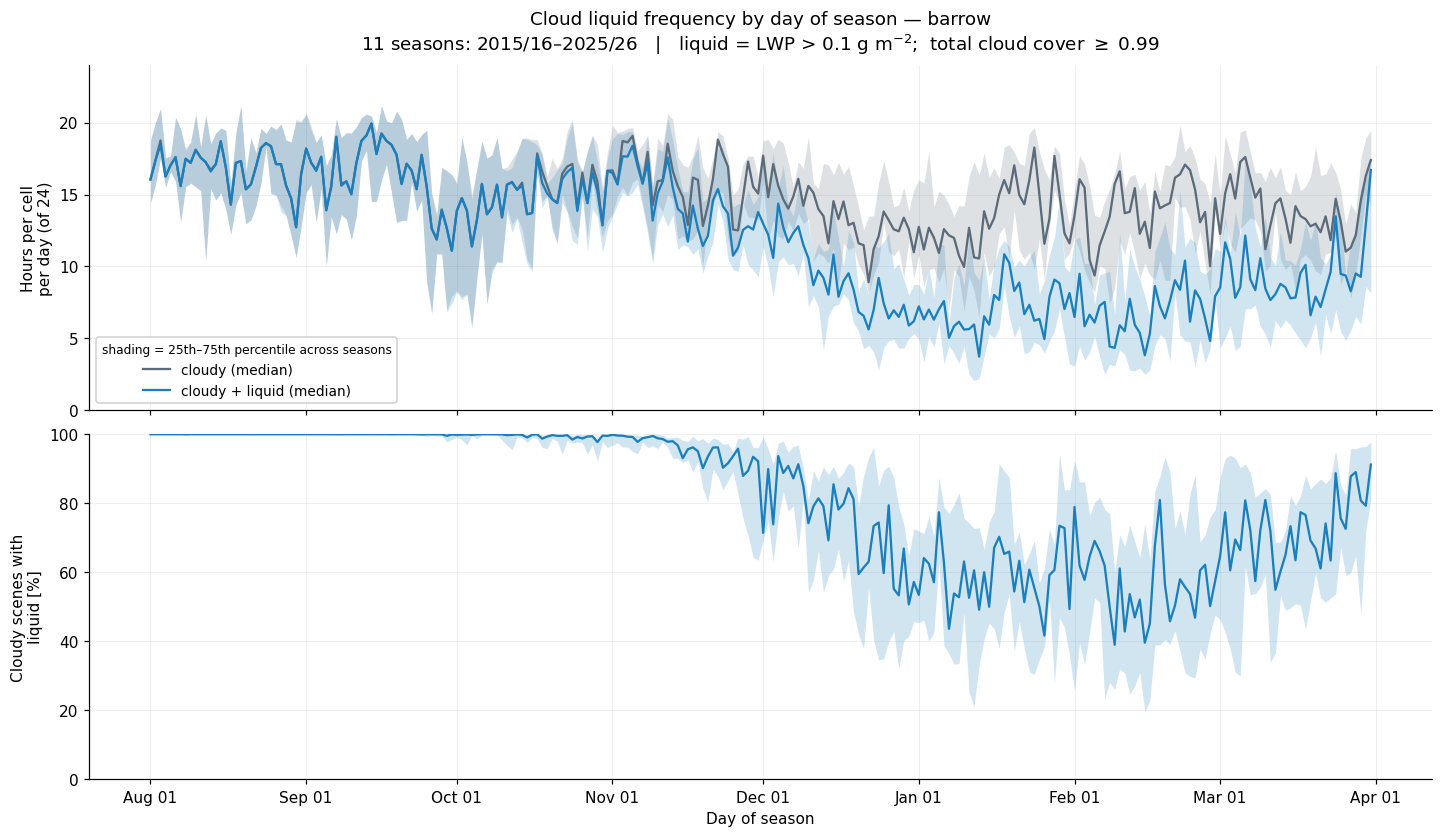

In [6]:
acl.fig_daily_liquid(A, out_dir=SAVE_DIR);

### 3. Monthly condensate paths

Mean LWP and IWP in cloudy scenes. With `include_precip=True` the precipitating species (`tcsw`, `tcrw`) are shown too — ERA5's IWP is suspended cloud ice only.

  -> figures/barrow_cloud_condensate_monthly.png


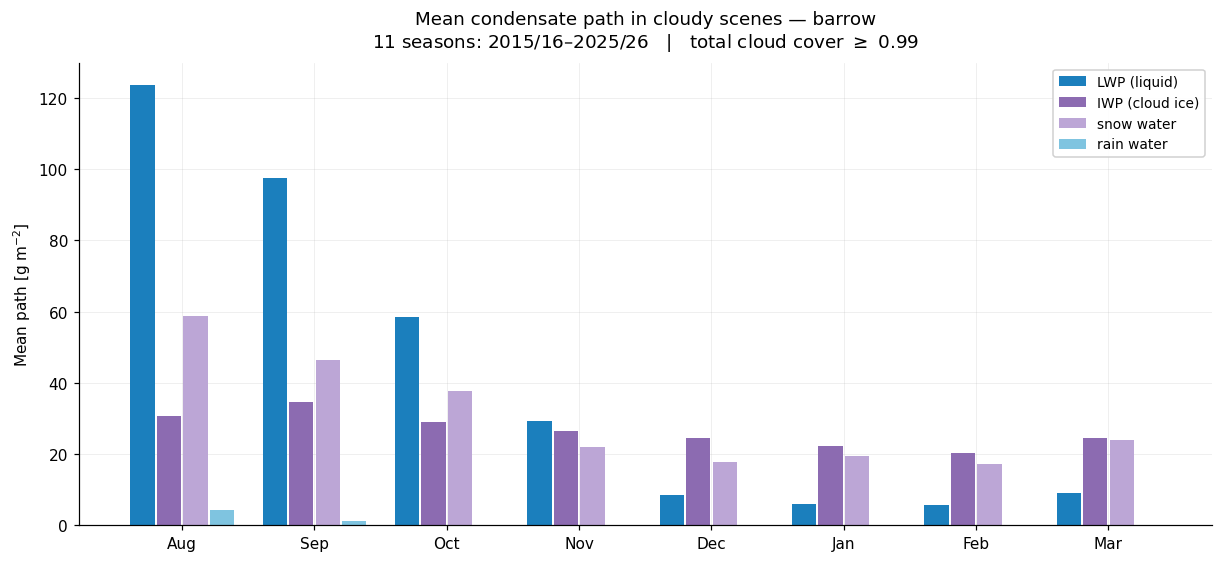

In [7]:
acl.fig_condensate_monthly(A, out_dir=SAVE_DIR);

### 4. Daily condensate paths

The same paths by day of season, with the interquartile band across seasons.

In [ ]:
acl.fig_condensate_daily(A, out_dir=SAVE_DIR);

### 5. Hours per cell-day with a liquid-bearing cloud

Different sample unit from figure 2: one **cell-day**, pooled over every cell and every season, so the quantiles describe a typical grid cell rather than the strip average.

In [ ]:
acl.fig_liquid_hours(A, out_dir=SAVE_DIR);

### 6. Cloudy hours by LWP

One panel per month, log-spaced bins. The leftmost bar is overcast with LWP at or below the threshold; the dotted line is the monthly median.


    Median LWP over cloudy scenes with liquid present (LWP > threshold):
      Aug      98.51 g m-2
      Sep      85.88 g m-2
      Oct      47.70 g m-2
      Nov      16.97 g m-2
      Dec       5.19 g m-2
      Jan       3.11 g m-2
      Feb       3.30 g m-2
      Mar       4.36 g m-2
  -> figures/barrow_cloud_lwp_histogram.png


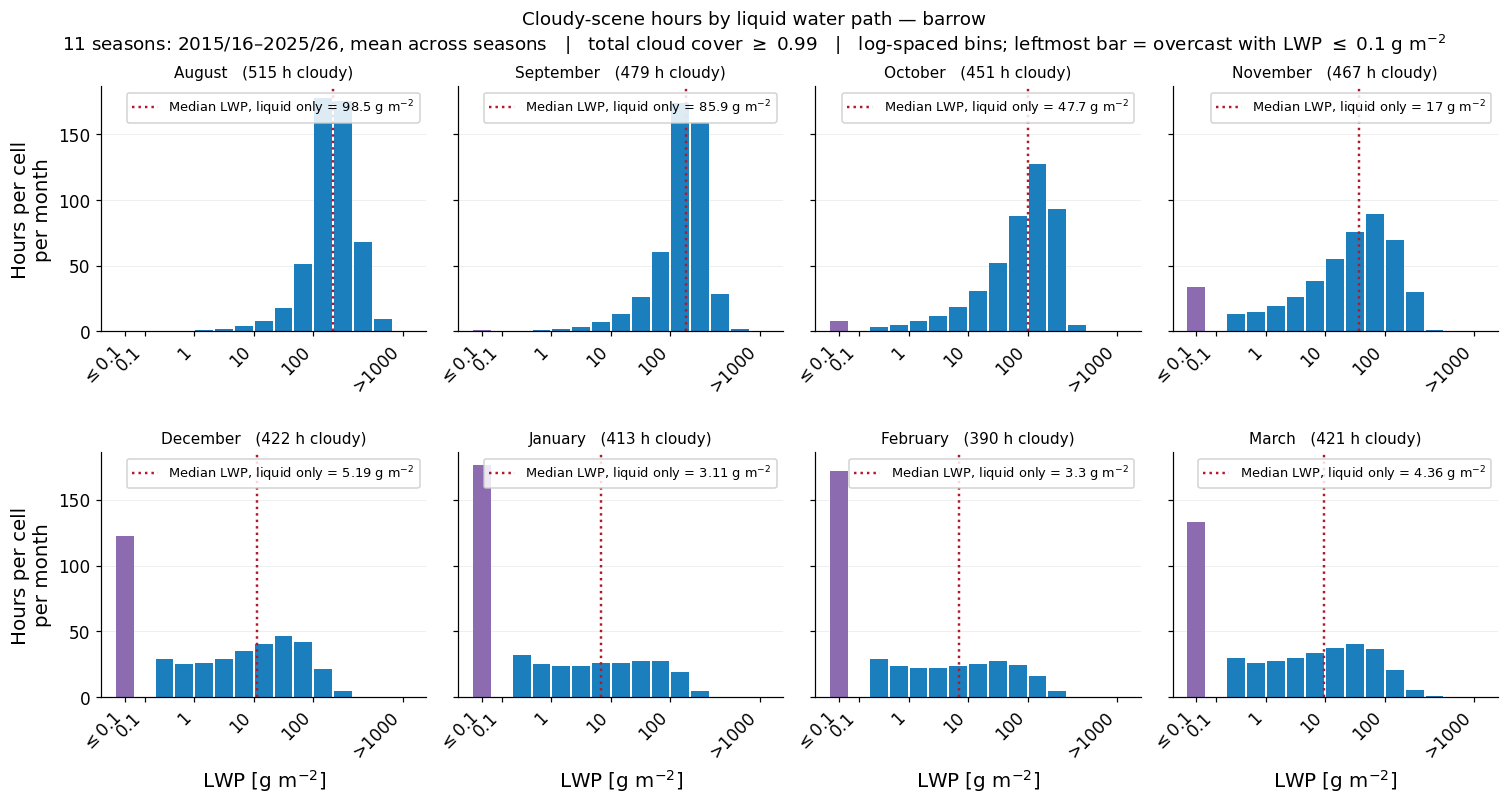

In [4]:
acl.fig_lwp_histogram(A, out_dir=SAVE_DIR);

### 7. Episode duration vs the sampling interval

How long overcast episodes last, against the 1-hour grid the instantaneous fields are sampled on, with a memoryless benchmark.

In [ ]:
acl.fig_episode_duration(A, out_dir=SAVE_DIR);

## Redraw everything

Same set the command-line run writes.

In [ ]:
for fn in acl.ALL_FIGURES:
    fn(A, out_dir=SAVE_DIR);

## Changing options

Anything that alters what is loaded or masked — region, years, season window,
thresholds, `ocean_only` — needs a fresh `prepare()`:

```python
A_ocean = acl.prepare(region="barrow", years=(2019, 2020), ocean_only=True)
acl.fig_lwp_histogram(A_ocean)
```

Options that only affect drawing can be changed on the existing `A` without
reloading, since the figures read them at draw time:

```python
A.args.include_precip = False
acl.fig_condensate_monthly(A)

A.args.hist_layout = (4, 2)
acl.fig_lwp_histogram(A)
```